In [2]:
import sys
!{sys.executable} -m pip install numpy matplotlib tensorflow pillow scikit-learn pandas kaggle kagglehub gradio

Defaulting to user installation because normal site-packages is not writeable
  Using cached numpy-2.4.2-cp313-cp313-win_amd64.whl.metadata (6.6 kB)
  Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached pandas-3.0.1-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached scipy-1.17.1-cp313-cp313-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached markupsafe-3.0.3-cp313-cp313-win_amd64.whl.metadata (2.8 kB)
  Using cached click-8.3.1-py3-none-any.whl.metadata (2.6 kB)
Using cached numpy-2.4.2-cp313-cp313-win_amd64.whl (12.3 MB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   --- ------------------------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\rohit\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
!pip install -q kaggle "tensorflow>=2.17.0" gradio matplotlib


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\rohit\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [7]:
import os

# possible dataset locations
paths = [
    "/kaggle/input/new-plant-diseases-dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)",  # Kaggle
    "/content/new-plant-diseases-dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)",       # Colab
    "../Dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"                                 # Local VS Code
]

main_folder = None

for p in paths:
    if os.path.exists(p):
        main_folder = p
        break

if main_folder is None:
    raise Exception("Dataset path not found")

print("Dataset found at:", main_folder)

Dataset found at: ../Dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)


In [10]:
train_dir = os.path.join(main_folder, "train")
valid_dir = os.path.join(main_folder, "valid")

print("Train folder:", train_dir)
print("Valid folder:", valid_dir)

print(os.listdir(main_folder))

print("Number of classes:", len(os.listdir(train_dir)))

Train folder: ../Dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)\train
Valid folder: ../Dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)\valid
['train', 'valid']
Number of classes: 38


In [13]:
import os

main_folder = "../Dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"

train_path = os.path.join(main_folder, "train")

classes = os.listdir(train_path)

print("Number of classes:", len(classes))
print(classes[:10])

Number of classes: 38
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___healthy']


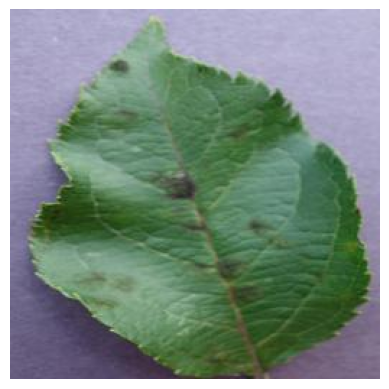

In [14]:
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

class_folder = os.path.join(train_path, classes[0])
images = os.listdir(class_folder)

img_path = os.path.join(class_folder, images[0])

img = image.load_img(img_path)

plt.imshow(img)
plt.axis("off")
plt.show()

In [15]:
import os
import sys
import random
import matplotlib.pyplot as plt
from IPython.display import Image, display

In [16]:
def count_images(directory):

    total_images = 0
    class_counts = {}

    for class_name in os.listdir(directory):

        class_path = os.path.join(directory, class_name)

        if os.path.isdir(class_path):
            num_images = len(os.listdir(class_path))

            class_counts[class_name] = num_images
            total_images += num_images

    return total_images, class_counts

In [17]:
train_total, train_counts = count_images(train_dir)
valid_total, valid_counts = count_images(valid_dir)

print("Training images:", train_total)
print("Validation images:", valid_total)
print("Number of classes:", len(train_counts))

print("\nClass distribution (first 10):")
for i, (class_name, count) in enumerate(list(train_counts.items())[:10]):
    print(f"{class_name}: {count} images")

Training images: 70295
Validation images: 17572
Number of classes: 38

Class distribution (first 10):
Apple___Apple_scab: 2016 images
Apple___Black_rot: 1987 images
Apple___Cedar_apple_rust: 1760 images
Apple___healthy: 2008 images
Blueberry___healthy: 1816 images
Cherry_(including_sour)___healthy: 1826 images
Cherry_(including_sour)___Powdery_mildew: 1683 images
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 1642 images
Corn_(maize)___Common_rust_: 1907 images
Corn_(maize)___healthy: 1859 images


In [18]:
def show_sample_images(base_path, num_classes=5, images_per_class=3):

    class_names = os.listdir(base_path)
    random_classes = random.sample(class_names, min(num_classes, len(class_names)))

    fig, axes = plt.subplots(num_classes, images_per_class, figsize=(12, 3*num_classes))
    fig.suptitle("Sample Images from Dataset", fontsize=16)

    for i, class_name in enumerate(random_classes):

        class_path = os.path.join(base_path, class_name)
        images = os.listdir(class_path)
        random_images = random.sample(images, min(images_per_class, len(images)))

        for j, img_name in enumerate(random_images):

            img_path = os.path.join(class_path, img_name)
            img = plt.imread(img_path)

            axes[i, j].imshow(img)
            axes[i, j].axis("off")

            if j == 0:
                axes[i, j].set_title(class_name.replace("___", "\n"), fontsize=10)

    plt.tight_layout()
    plt.show()

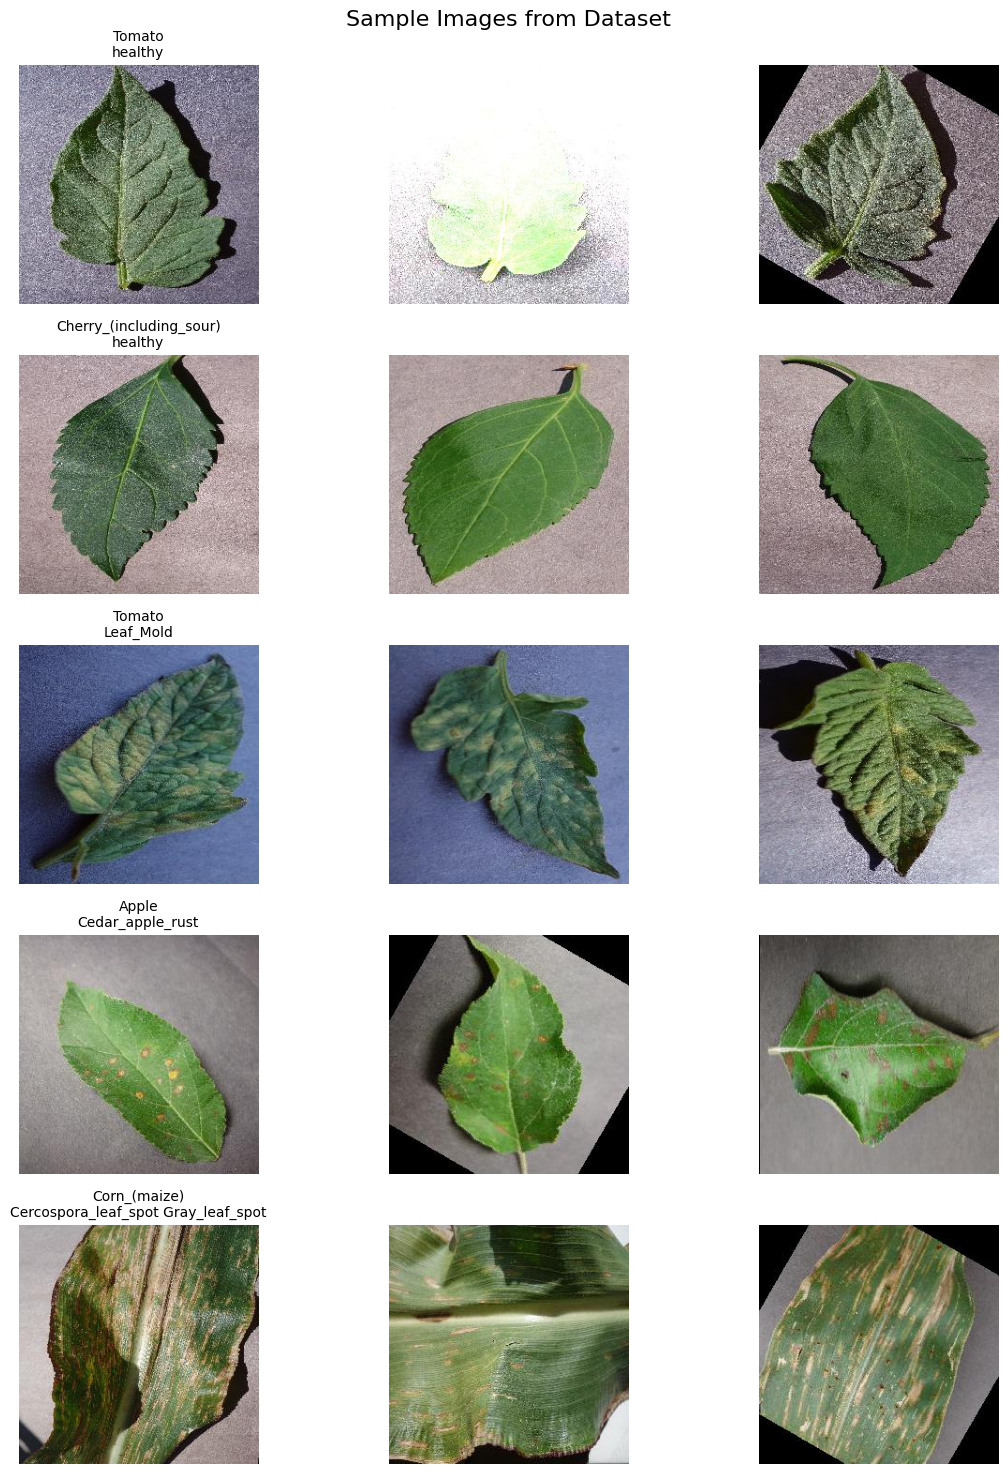

In [19]:
show_sample_images(train_dir)

In [20]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 5
SEED = 1337

In [21]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Training data generator with light augmentation
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    horizontal_flip=True,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    fill_mode='reflect'
)

# Validation data generator (no augmentation)
valid_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# Create data generators
train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

valid_gen = valid_datagen.flow_from_directory(
    valid_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.


In [22]:
#Load Pre-trained MobileNetV2
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

print("Base model loaded")
base_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Base model loaded


Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 2,223,872 (8.48 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [23]:
# Configure Transfer Learning Strategy
for layer in base_model.layers:
    layer.trainable = False

print("All base model layers frozen")

N_LAST_LAYERS = 10

for layer in base_model.layers[-N_LAST_LAYERS:]:
    layer.trainable = True

print("Last", N_LAST_LAYERS, "layers unfrozen")

trainable_count = sum([1 for layer in base_model.layers if layer.trainable])

print("Trainable layers:", trainable_count)
print("Total layers:", len(base_model.layers))

All base model layers frozen
Last 10 layers unfrozen
Trainable layers: 10
Total layers: 154


In [24]:
#Compile the model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)

predictions = Dense(38, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully")

Model compiled successfully


In [25]:
#Setup training callbacks
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=1e-6
)

callbacks = [checkpoint, early_stop, reduce_lr]

In [29]:
#Train the model
history = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step - accuracy: 0.9464 - loss: 0.1739
Epoch 1: val_accuracy improved from None to 0.95214, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 957s 436ms/step - accuracy: 0.9493 - loss: 0.1619 - val_accuracy: 0.9521 - val_loss: 0.1466 - learning_rate: 1.0000e-04
Epoch 2/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 535ms/step - accuracy: 0.9598 - loss: 0.1232
Epoch 2: val_accuracy did not improve from 0.95214
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1308s 596ms/step - accuracy: 0.9607 - loss: 0.1221 - val_accuracy: 0.9452 - val_loss: 0.1761 - learning_rate: 1.0000e-04
Epoch 3/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 882ms/step - accuracy: 0.9679 - loss: 0.1033
Epoch 3: val_accuracy improved from 0.95214 to 0.96494, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 2282s 1s/step - accuracy: 0.9676 - loss: 0.1018 - val_accuracy: 0.9649 - val_loss: 0.1032 - learning_rate: 1.0000e-04
Epoch 4/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 824ms/step - accuracy: 0.9715 - loss: 0.0860
Epoch 4: val_accuracy did not improve from 0.96494
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 2034s 916ms/step - accuracy: 0.9716 - loss: 0.0866 - val_accuracy: 0.9565 - val_loss: 0.1320 - learning_rate: 1.0000e-04
Epoch 5/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 526ms/step - accuracy: 0.9731 - loss: 0.0830
Epoch 5: val_accuracy improved from 0.96494 to 0.96807, saving model to best_model.h5



Epoch 5: finished saving model to best_model.h5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1339s 587ms/step - accuracy: 0.9737 - loss: 0.0812 - val_accuracy: 0.9681 - val_loss: 0.0910 - learning_rate: 1.0000e-04


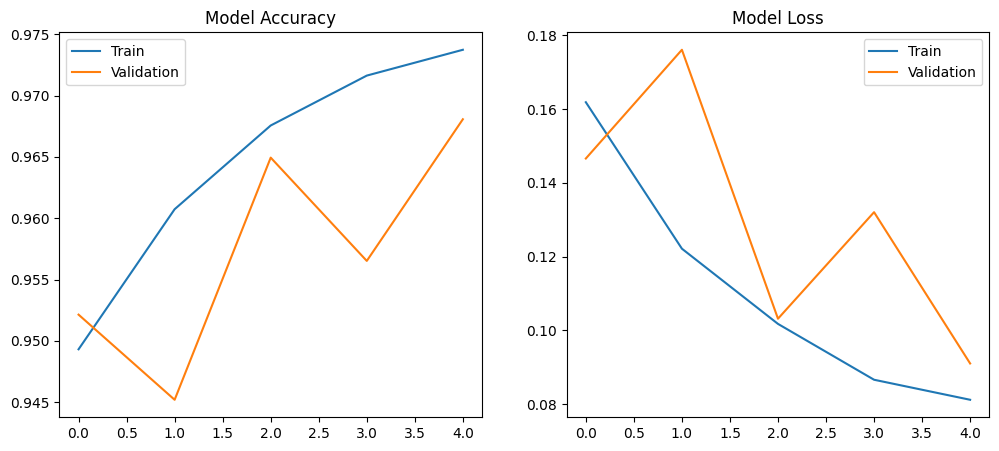

In [30]:
#Visualize Training data
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.legend(["Train","Validation"])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.legend(["Train","Validation"])

plt.show()

In [31]:
#Evaluate model performance
test_loss, test_accuracy = model.evaluate(valid_gen)

print("Validation Loss:", test_loss)
print("Validation Accuracy:", test_accuracy)

550/550 ━━━━━━━━━━━━━━━━━━━━ 147s 267ms/step - accuracy: 0.9681 - loss: 0.0910
Validation Loss: 0.09103316813707352
Validation Accuracy: 0.9680742025375366


In [32]:
model.save("plant_disease_model.h5")